# RSP Time-Dependent OTAP — `td.ipynb`

**Purpose:** Use the `rsp` SDK to run Yang and Zhou time-dependent OTAP (`Yang_OTAP_ILP`) from network data.

This notebook mirrors `notebook/mp.ipynb` and focuses on three workflows:

1. Read an existing network dataset and convert it into a time-dependent dataset.
2. Solve one OD pair and inspect the selected path and metrics.
3. Run multiple OD pairs and report experiment-level metrics.

Current first-version design: Cao-style static samples `W[sample, edge]` are lifted into Yang-style time-dependent samples `TD[sample, time_step, edge]` by a time profile:

```text
TD[k, t, e] = W[k, e] * time_profile[t]
```


## 1. Setup — Imports & Path

In [26]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve repo root — works from workspace root or notebook/ dir
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebook" and (REPO_ROOT.parent / "rsp" / "__init__.py").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rsp import RSPConfig, RSPDataset, RSPRunner, RSPTimeDependentDataset

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print(f"Repo root : {REPO_ROOT}")

Repo root : /home/kkk/projects/RSP


## 2. Configuration

The example reads the existing Cao network/data directory, then constructs a Yang time-dependent dataset from it.

The exact Yang OTAP ILP expands by `samples × time_steps × edges`. For an interactive notebook, the source dataset remains `full/seed524`, but the solver demo uses a bounded sample subset. The time horizon is now selected inside `RSPTimeDependentDataset.from_cao_dataset(..., auto_horizon=True)`, so you do not need to manually guess `TIME_PROFILE_LENGTH`.


In [27]:
# ============================================================
# Source network dataset — uncomment one
# ============================================================
# DATASET_PATH = str(REPO_ROOT / "Cao_SOTA_MP/data/small")             # 10 nodes, fast debug
# DATASET_PATH = str(REPO_ROOT / "Cao_SOTA_MP/data/full/seed42")       # 65 nodes, larger artificial data
DATASET_PATH = str(
    REPO_ROOT / "Cao_SOTA_MP/data/full/seed524"
)  # 65 nodes, seed524 artificial data
# DATASET_PATH = str(REPO_ROOT / "Cao_SOTA_MP/data/beijing")           # 587 nodes, Beijing OSM
# DATASET_PATH = str(REPO_ROOT / "Cao_SOTA_MP/data/beijing_conflict")  # 587 nodes, conflict variance

# ============================================================
# Time-dependent conversion
# ============================================================
# TD[k,t,e] = W[k,e] * time_profile[t]
# Keep the notebook demo bounded in samples; horizon is extended by the SDK if needed.
SAMPLE_LIMIT = 50
BASE_TIME_FACTOR = 0.005
time_profile = [BASE_TIME_FACTOR]
TIME_STEP = 0.05
HORIZON_PADDING_STEPS = 0

# We read the full seed524 dataset, then solve selected OD cases on the sample subset.
# Keep notebook defaults small; append harder OD indices manually for longer runs.
MULTI_OD_INDICES = [18, 19, 1, 2]
SINGLE_SOURCE_OD_INDEX = 18
SINGLE_OD_LOCAL_IDX = 0

# ============================================================
# Config — inline construction
# ============================================================
SOLVER_BACKEND = (
    "SCIP"  # Cao large experiments use SCIP; CBC is available but slower here.
)
TIME_LIMIT = 30

config_single = RSPConfig(
    methods=("Yang_OTAP_ILP",),
    alphas=(0.7,),
    num_repeats=1,
    num_od_pairs=1,
    solver_backend=SOLVER_BACKEND,
    time_limit=TIME_LIMIT,
    deadline_mode="heuristic",  # heuristic / exact
)

config_multi = RSPConfig(
    methods=("Yang_OTAP_ILP",),
    alphas=(0.5, 0.7),
    num_repeats=1,
    num_od_pairs=len(MULTI_OD_INDICES),
    solver_backend=SOLVER_BACKEND,
    time_limit=TIME_LIMIT,
    deadline_mode="heuristic",
)

print(f"Dataset       : {DATASET_PATH}")
print(f"Solver        : {SOLVER_BACKEND}, time_limit={TIME_LIMIT}s")
print(f"Demo samples  : first {SAMPLE_LIMIT} samples from repeat 0")
print(f"Base profile  : len={len(time_profile)}, first={time_profile[0]}")
print(
    f"Single config : methods={list(config_single.methods)}, alphas={list(config_single.alphas)}"
)
print(
    f"Multi config  : methods={list(config_multi.methods)}, alphas={list(config_multi.alphas)}, jobs={config_multi.expected_job_count}"
)


Dataset       : /home/kkk/projects/RSP/Cao_SOTA_MP/data/full/seed524
Solver        : SCIP, time_limit=30s
Demo samples  : first 50 samples from repeat 0
Base profile  : len=1, first=0.005
Single config : methods=['Yang_OTAP_ILP'], alphas=[0.7]
Multi config  : methods=['Yang_OTAP_ILP'], alphas=[0.5, 0.7], jobs=8


## 3. Load Network Data

This section is deliberately explicit: first load the original network and static travel-time samples, then convert them into the time-dependent dataset used by Yang OTAP.

In [28]:
cao_dataset = RSPDataset.from_directory(DATASET_PATH)

print("=== Source Cao Dataset ===")
print(f"Nodes       : {cao_dataset.network.num_nodes}")
print(f"Edges       : {cao_dataset.network.num_edges}")
print(f"Repeats     : {cao_dataset.num_repeats}")
print(f"OD pairs    : {cao_dataset.num_od_pairs}")
print(f"Samples (N) : {cao_dataset.travel_times[0].shape[0]}")
print(f"W shape     : {cao_dataset.travel_times[0].shape}")
print(f"OD list     : {cao_dataset.od_pairs}")

=== Source Cao Dataset ===
Nodes       : 65
Edges       : 123
Repeats     : 10
OD pairs    : 20
Samples (N) : 500
W shape     : (500, 123)
OD list     : [(11, 32), (47, 24), (24, 16), (61, 47), (50, 35), (62, 50), (32, 44), (50, 22), (61, 4), (45, 16), (53, 49), (1, 32), (59, 32), (32, 16), (19, 21), (41, 63), (41, 60), (44, 45), (13, 35), (11, 24)]


### 3a. Convert Cao Samples to Time-Dependent Samples

In [29]:
sample_limit = min(SAMPLE_LIMIT, cao_dataset.travel_times[0].shape[0])
single_od_pair = cao_dataset.od_pairs[SINGLE_SOURCE_OD_INDEX]
selected_od_pairs = [cao_dataset.od_pairs[i] for i in MULTI_OD_INDICES]

# Build a small single-OD dataset separately, so the single-case solve is not
# forced to use the longest horizon required by the multi-OD batch.
cao_single_dataset = RSPDataset.from_arrays(
    network=cao_dataset.network,
    travel_times=[cao_dataset.travel_times[0][:sample_limit]],
    od_pairs=[single_od_pair],
    meta={
        **cao_dataset.meta,
        "source_dataset": DATASET_PATH,
        "selected_source_od_indices": [SINGLE_SOURCE_OD_INDEX],
        "sample_limit": sample_limit,
        "notebook_mode": "single_od_interactive_subset",
    },
)
td_single_dataset = RSPTimeDependentDataset.from_cao_dataset(
    cao_single_dataset,
    time_profile=time_profile,
    time_step=TIME_STEP,
    horizon_padding_steps=HORIZON_PADDING_STEPS,
    meta={
        "conversion": "TD[k,t,e] = W[k,e] * time_profile[t]",
        "solver_scale_note": "single-OD interactive subset with SDK auto horizon",
    },
)

# For multi-OD we do not build one shared TD tensor here. Each OD will build
# its own one-OD TD tensor in the loop, so easy ODs are not forced to use the
# longest horizon required by hard ODs.
multi_horizon_preview = []
for source_od_idx, od_pair in zip(MULTI_OD_INDICES, selected_od_pairs):
    od_dataset = RSPDataset.from_arrays(
        network=cao_dataset.network,
        travel_times=[cao_dataset.travel_times[0][:sample_limit]],
        od_pairs=[od_pair],
    )
    steps = RSPTimeDependentDataset.recommend_cao_time_horizon_steps(
        dataset=od_dataset,
        time_profile=time_profile,
        time_step=TIME_STEP,
        padding_steps=HORIZON_PADDING_STEPS,
    )
    multi_horizon_preview.append(
        {
            "source_od_idx": source_od_idx,
            "origin": od_pair[0],
            "destination": od_pair[1],
            "recommended_T": steps,
        }
    )


def print_td_dataset_info(name, dataset, source_indices):
    print(f"=== {name} ===")
    print(
        f"TD shape       : {dataset.travel_times[0].shape}  # samples, time_steps, edges"
    )
    print(f"Deadline W     : {dataset.deadline_matrix().shape}  # samples, edges")
    print(f"Time step      : {dataset.time_step}")
    print(
        f"Auto horizon   : input T={dataset.meta.get('input_time_profile_length')}, "
        f"actual T={dataset.num_time_steps}, "
        f"added={dataset.meta.get('auto_horizon_added_steps')}"
    )
    print(f"Selected ODs   : {dataset.od_pairs}")
    print(f"Source OD idx  : {source_indices}")


print(f"Source W shape : {cao_dataset.travel_times[0].shape}  # full seed524 repeat 0")
print_td_dataset_info(
    "Single-OD Time-Dependent Dataset", td_single_dataset, [SINGLE_SOURCE_OD_INDEX]
)
print("=== Multi-OD Horizon Preview ===")
display(pd.DataFrame(multi_horizon_preview))
print(f"Edge order head: {td_single_dataset.edge_order[:5]}")


Source W shape : (500, 123)  # full seed524 repeat 0
=== Single-OD Time-Dependent Dataset ===
TD shape       : (50, 9, 123)  # samples, time_steps, edges
Deadline W     : (50, 123)  # samples, edges
Time step      : 0.05
Auto horizon   : input T=1, actual T=9, added=8
Selected ODs   : [(13, 35)]
Source OD idx  : [18]
=== Multi-OD Horizon Preview ===


,source_od_idx,origin,destination,recommended_T
0,18,13,35,9
1,19,11,24,20
2,1,47,24,25
3,2,24,16,74


Edge order head: [(0, 32), (1, 17), (1, 48), (1, 16), (2, 60)]


### 3b. Inspect Network & Travel Times

In [30]:
W_deadline = td_single_dataset.deadline_matrix(repeat=0)
TD0 = td_single_dataset.travel_times[0]
edge_means = W_deadline.mean(axis=0)
edge_cvs = W_deadline.std(axis=0) / edge_means

print(
    f"Deadline-matrix edge mean travel time: [{edge_means.min():.2f}, {edge_means.max():.2f}]"
)
print(
    f"Deadline-matrix edge CV — median: {np.median(edge_cvs):.3f}, "
    f"range: [{edge_cvs.min():.3f}, {edge_cvs.max():.3f}]"
)
print(f"TD min/max: [{TD0.min():.2f}, {TD0.max():.2f}]")
print(f"N samples : {TD0.shape[0]}")
print(f"T steps   : {TD0.shape[1]}")
print(f"E edges   : {TD0.shape[2]}")


Deadline-matrix edge mean travel time: [0.04, 0.48]
Deadline-matrix edge CV — median: 0.627, range: [0.197, 1.320]
TD min/max: [0.00, 1.62]
N samples : 50
T steps   : 9
E edges   : 123


## 4. Single OD — Solve One Case

In [31]:
single_runner = RSPRunner(td_single_dataset, config_single)

REPEAT = 0
OD_IDX = SINGLE_OD_LOCAL_IDX
ALPHA = config_single.alphas[0]

origin, dest = td_single_dataset.od_pairs[OD_IDX]
case = single_runner.solve_case(repeat=REPEAT, od_idx=OD_IDX, alpha=ALPHA)
yang = case.metrics["methods"]["Yang_OTAP_ILP"]
N = td_single_dataset.num_samples

print(f"OD          : {origin} → {dest}")
print(f"α           : {ALPHA}")
print(f"τ (tau)     : {case.tau:.4f}")
print(f"TD shape    : {td_single_dataset.travel_times[0].shape}")
print(f"Status      : {yang['status']}")
print(
    f"Punctuality : {yang['punctuality_prob']:.4f}  ({yang['lateness_count']}/{N} late)"
)
print(f"On time     : {yang['on_time_count']}/{N}")
print(f"Path length : {yang['path_length']}")
print(f"Mean time   : {yang['mean_time']:.4f}")
print(f"Max delay   : {yang['max_delay']:.4f}")
print(f"Solve time  : {yang['solve_time']:.4f} s")
print(f"Conclusion  : {yang['conclusion']}")


OD          : 13 → 35
α           : 0.7
τ (tau)     : 0.3391
TD shape    : (50, 9, 123)
Status      : Optimal
Punctuality : 0.7600  (12/50 late)
On time     : 38/50
Path length : 1
Mean time   : 0.2810
Max delay   : 0.1109
Solve time  : 0.7633 s
Conclusion  : Yang_OTAP_ILP found path [(13, 35)] with on-time probability 0.76 under threshold 0.339109; 38/50 samples arrive on time.


### 4a. Display the OTAP Path

In [32]:
if yang["path_edges"] is not None:
    path_edges = yang["path_edges"]
    node_seq = [path_edges[0][0]]
    for u, v in path_edges:
        node_seq.append(v)

    print(f"Yang_OTAP_ILP path ({len(path_edges)} edges, {len(path_edges) + 1} nodes):")
    print(f"  Nodes: {' → '.join(str(n) for n in node_seq)}")

    for j, (u, v) in enumerate(path_edges):
        edge_idx = td_single_dataset.edge_order.index((u, v))
        mean_t = td_single_dataset.travel_times[0][:, :, edge_idx].mean()
        deadline_mean = td_single_dataset.deadline_matrix(repeat=0)[:, edge_idx].mean()
        print(
            f"  Edge {j}: ({u}→{v})  "
            f"[edge_order idx={edge_idx}, TD mean={mean_t:.2f}, deadline mean={deadline_mean:.2f}]"
        )

    sample_times = np.asarray(yang["sample_travel_times"], dtype=float)
    print("Selected path time-dependent sample stats:")
    print(f"  Mean: {sample_times.mean():.2f}   Median: {np.median(sample_times):.2f}")
    print(f"  Min : {sample_times.min():.2f}   Max:    {sample_times.max():.2f}")
    print(f"  Late: {(sample_times > case.tau).sum()}/{N}  (>{case.tau:.2f})")
else:
    print(f"Yang_OTAP_ILP did not return a path. Status: {yang['status']}")

Yang_OTAP_ILP path (1 edges, 2 nodes):
  Nodes: 13 → 35
  Edge 0: (13→35)  [edge_order idx=31, TD mean=0.26, deadline mean=0.26]
Selected path time-dependent sample stats:
  Mean: 0.28   Median: 0.28
  Min : 0.20   Max:    0.45
  Late: 12/50  (>0.34)


### 4b. Path Travel-Time Histogram

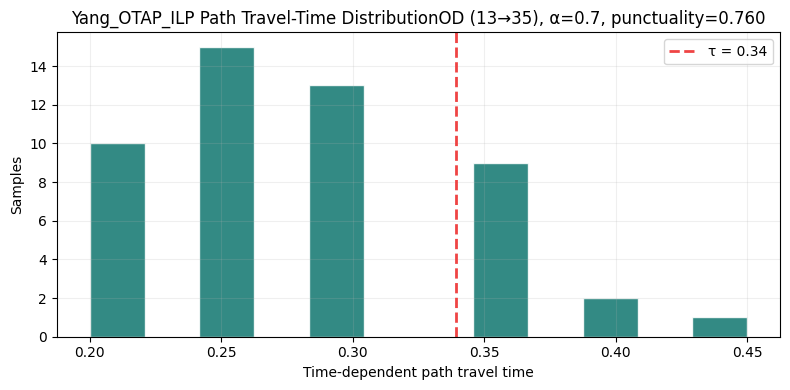

In [33]:
if yang["sample_travel_times"] is not None:
    sample_times = np.asarray(yang["sample_travel_times"], dtype=float)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(sample_times, bins=12, color="#0f766e", edgecolor="white", alpha=0.85)
    ax.axvline(
        case.tau,
        color="#ef4444",
        linestyle="--",
        linewidth=2,
        label=f"τ = {case.tau:.2f}",
    )
    ax.set_xlabel("Time-dependent path travel time")
    ax.set_ylabel("Samples")
    ax.set_title(
        f"Yang_OTAP_ILP Path Travel-Time Distribution"
        f"OD ({origin}→{dest}), α={ALPHA}, "
        f"punctuality={yang['punctuality_prob']:.3f}"
    )
    ax.legend()
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    plt.show()

## 5. Multi-OD — Sequential Single-OD Runs

Run each OD/alpha case one by one, print progress immediately, and then aggregate all rows into one `RSPResult`. This is easier to monitor than a single batch call when some OD pairs are infeasible or slow.


In [34]:
import time
from rsp.result import RSPResult

rows = []
case_records = []
total_jobs = len(MULTI_OD_INDICES) * len(config_multi.alphas)
job_idx = 0

t0 = time.perf_counter()
for local_od_idx, source_od_idx in enumerate(MULTI_OD_INDICES):
    od_pair = cao_dataset.od_pairs[source_od_idx]
    cao_od_dataset = RSPDataset.from_arrays(
        network=cao_dataset.network,
        travel_times=[cao_dataset.travel_times[0][:sample_limit]],
        od_pairs=[od_pair],
        meta={
            **cao_dataset.meta,
            "source_dataset": DATASET_PATH,
            "selected_source_od_indices": [source_od_idx],
            "sample_limit": sample_limit,
            "notebook_mode": "multi_od_per_od_horizon",
        },
    )
    td_od_dataset = RSPTimeDependentDataset.from_cao_dataset(
        cao_od_dataset,
        time_profile=time_profile,
        time_step=TIME_STEP,
        horizon_padding_steps=HORIZON_PADDING_STEPS,
        meta={
            "conversion": "TD[k,t,e] = W[k,e] * time_profile[t]",
            "source_od_idx": source_od_idx,
        },
    )
    od_config = RSPConfig(
        methods=config_multi.methods,
        alphas=config_multi.alphas,
        num_repeats=1,
        num_od_pairs=1,
        solver_backend=config_multi.solver_backend,
        big_m=config_multi.big_m,
        time_limit=config_multi.time_limit,
        deadline_mode=config_multi.deadline_mode,
        deadline_enumeration_cutoff=config_multi.deadline_enumeration_cutoff,
        max_candidate_paths=config_multi.max_candidate_paths,
        random_seed=config_multi.random_seed,
    )
    od_runner = RSPRunner(td_od_dataset, od_config)

    for alpha in config_multi.alphas:
        job_idx += 1
        case_start = time.perf_counter()
        case_m = od_runner.solve_case(repeat=0, od_idx=0, alpha=float(alpha))
        case_elapsed = time.perf_counter() - case_start
        y = case_m.metrics["methods"]["Yang_OTAP_ILP"]

        for row in od_runner._case_to_rows(case_m):
            row["od_idx"] = local_od_idx
            row["source_od_idx"] = source_od_idx
            row["td_time_steps"] = td_od_dataset.num_time_steps
            rows.append(row)
        case_m.metrics["od_idx"] = local_od_idx
        case_m.metrics["source_od_idx"] = source_od_idx
        case_m.metrics["td_time_steps"] = td_od_dataset.num_time_steps
        case_records.append(case_m)

        punct = y.get("punctuality_prob")
        late = y.get("lateness_count")
        path_len = y.get("path_length")
        punct_text = "NA" if punct is None else f"{punct:.3f}"
        late_text = "NA" if late is None else f"{late}/{td_od_dataset.num_samples}"
        path_text = "NA" if path_len is None else str(int(path_len))
        print(
            f"[{job_idx}/{total_jobs}] source_od={source_od_idx} local_od={local_od_idx} "
            f"({od_pair[0]}->{od_pair[1]}) T={td_od_dataset.num_time_steps} alpha={alpha:.2f} "
            f"tau={case_m.tau:.4f} status={y.get('status')} "
            f"punct={punct_text} late={late_text} "
            f"path_len={path_text} wall={case_elapsed:.2f}s"
        )

elapsed = time.perf_counter() - t0
result = RSPResult(
    df=pd.DataFrame(rows),
    config=config_multi,
    dataset_meta={
        "source_dataset": DATASET_PATH,
        "selected_source_od_indices": MULTI_OD_INDICES,
        "sample_limit": sample_limit,
        "notebook_mode": "multi_od_per_od_horizon",
    },
)
df = result.to_dataframe()

print(f"Done in {elapsed:.1f}s — {len(df)} rows")
display(
    df[
        [
            "repeat",
            "od_idx",
            "source_od_idx",
            "origin",
            "destination",
            "td_time_steps",
            "alpha",
            "tau",
            "method",
            "status",
            "punctuality_prob",
            "on_time_count",
            "lateness_count",
            "path_length",
            "mean_time",
            "max_delay",
            "solve_time",
            "path_edges",
        ]
    ].round(4)
)


[1/8] source_od=18 local_od=0 (13->35) T=9 alpha=0.50 tau=0.2912 status=Optimal punct=0.500 late=25/50 path_len=1 wall=2.25s
[2/8] source_od=18 local_od=0 (13->35) T=9 alpha=0.70 tau=0.3391 status=Optimal punct=0.760 late=12/50 path_len=1 wall=2.48s
[3/8] source_od=19 local_od=1 (11->24) T=20 alpha=0.50 tau=0.5151 status=Optimal punct=0.940 late=3/50 path_len=1 wall=11.84s
[4/8] source_od=19 local_od=1 (11->24) T=20 alpha=0.70 tau=0.7010 status=Optimal punct=0.980 late=1/50 path_len=1 wall=12.05s
[5/8] source_od=1 local_od=2 (47->24) T=25 alpha=0.50 tau=0.6581 status=Optimal punct=0.560 late=22/50 path_len=2 wall=16.74s
[6/8] source_od=1 local_od=2 (47->24) T=25 alpha=0.70 tau=0.7846 status=Optimal punct=0.780 late=11/50 path_len=2 wall=16.74s
[7/8] source_od=2 local_od=3 (24->16) T=74 alpha=0.50 tau=1.1680 status=Optimal punct=0.540 late=23/50 path_len=7 wall=144.54s
[8/8] source_od=2 local_od=3 (24->16) T=74 alpha=0.70 tau=1.4058 status=Optimal punct=0.740 late=13/50 path_len=7 wall=

,repeat,od_idx,source_od_idx,origin,destination,td_time_steps,alpha,tau,method,status,punctuality_prob,on_time_count,lateness_count,path_length,mean_time,max_delay,solve_time,path_edges
0,0,0,18,13,35,9,0.5,0.2912,Yang_OTAP_ILP,Optimal,0.50,25,25,1,0.281,0.1588,0.4063,"[(13, 35)]"
1,0,0,18,13,35,9,0.7,0.3391,Yang_OTAP_ILP,Optimal,0.76,38,12,1,0.281,0.1109,0.3798,"[(13, 35)]"
2,0,1,19,11,24,20,0.5,0.5151,Yang_OTAP_ILP,Optimal,0.94,47,3,1,0.289,0.4849,1.0959,"[(11, 24)]"
3,0,1,19,11,24,20,0.7,0.7010,Yang_OTAP_ILP,Optimal,0.98,49,1,1,0.289,0.2990,1.5536,"[(11, 24)]"
4,0,2,1,47,24,25,0.5,0.6581,Yang_OTAP_ILP,Optimal,0.56,28,22,2,0.667,0.3419,1.6426,"[(4, 24), (47, 4)]"
5,0,2,1,47,24,25,0.7,0.7846,Yang_OTAP_ILP,Optimal,0.78,39,11,2,0.667,0.2154,1.5915,"[(4, 24), (47, 4)]"
6,0,3,2,24,16,74,0.5,1.1680,Yang_OTAP_ILP,Optimal,0.54,27,23,7,1.239,0.7320,7.9579,"[(3, 16), (8, 64), (24, 41), (31, 3), (41, 56)..."
7,0,3,2,24,16,74,0.7,1.4058,Yang_OTAP_ILP,Optimal,0.74,37,13,7,1.239,0.4942,7.0777,"[(3, 16), (8, 64), (24, 41), (31, 3), (41, 56)..."


### 5a. Results — Summary by Alpha

In [35]:
by_alpha = result.by_alpha()
print("=== Yang_OTAP_ILP Results by Alpha ===")
display(by_alpha.round(4))

pivot = by_alpha.pivot(index="alpha", columns="method", values="mean_punctuality_prob")
print("=== Mean Punctuality vs Alpha ===")
display(pivot.round(4))

=== Yang_OTAP_ILP Results by Alpha ===


,alpha,method,mean_punctuality_prob,mean_solve_time_s,optimal_rate,reference_available_rate,tie_aware_accuracy,path_match_accuracy,mean_objective_gap,mean_lateness_count,mean_on_time_count
0,0.5,Yang_OTAP_ILP,0.635,2.7757,1.0,0.0,NaN,NaN,NaN,18.25,31.75
1,0.7,Yang_OTAP_ILP,0.815,2.6506,1.0,0.0,NaN,NaN,NaN,9.25,40.75


=== Mean Punctuality vs Alpha ===


method,Yang_OTAP_ILP
alpha,
0.5,0.635
0.7,0.815


### 5b. Results — By OD Pair

In [36]:
by_od = result.by_od()
print("=== Yang_OTAP_ILP Results by OD Pair ===")
display(by_od.round(4))

=== Yang_OTAP_ILP Results by OD Pair ===


,od_idx,method,mean_punctuality_prob,mean_solve_time_s,optimal_rate,reference_available_rate,tie_aware_accuracy,path_match_accuracy,mean_objective_gap,mean_lateness_count,mean_on_time_count
0,0,Yang_OTAP_ILP,0.63,0.3930,1.0,0.0,NaN,NaN,NaN,18.5,31.5
1,1,Yang_OTAP_ILP,0.96,1.3247,1.0,0.0,NaN,NaN,NaN,2.0,48.0
2,2,Yang_OTAP_ILP,0.67,1.6171,1.0,0.0,NaN,NaN,NaN,16.5,33.5
3,3,Yang_OTAP_ILP,0.64,7.5178,1.0,0.0,NaN,NaN,NaN,18.0,32.0


### 5c. Solve Time & Status

In [37]:
print("=== Solve Time ===")
display(result.solve_time().round(4))

print("=== Solver Status ===")
display(result.status_counts())

print("=== Summary ===")
display(result.summary().round(4))

=== Solve Time ===


,method,mean_solve_time_s,median_solve_time_s,max_solve_time_s,min_solve_time_s
0,Yang_OTAP_ILP,2.7132,1.5725,7.9579,0.3798


=== Solver Status ===


,method,status,count,rate
0,Yang_OTAP_ILP,Optimal,8,1.0


=== Summary ===


,method,mean_punctuality_prob,mean_solve_time_s,optimal_rate,reference_available_rate,tie_aware_accuracy,path_match_accuracy,mean_objective_gap,mean_lateness_count,mean_on_time_count
0,Yang_OTAP_ILP,0.725,2.7132,1.0,0.0,NaN,NaN,NaN,13.75,36.25


### 5d. Inspect Stored Case Paths

Use the cases already solved above, so this section does not re-run the optimizer.


In [38]:
for case_m in case_records:
    repeat = case_m.metrics["repeat"]
    od_idx = case_m.metrics["od_idx"]
    origin = case_m.metrics["origin"]
    destination = case_m.metrics["destination"]
    alpha = case_m.metrics["alpha"]
    y = case_m.metrics["methods"]["Yang_OTAP_ILP"]

    print(f"{'=' * 60}")
    print(f"repeat={repeat} OD {od_idx}: {origin} → {destination}, α={alpha:.2f}")
    print(f"τ={case_m.tau:.4f}, status={y.get('status')}")

    if y.get("path_edges") is None:
        print("No optimal path returned for this case.")
        continue

    path_edges = y["path_edges"]
    node_seq = [str(path_edges[0][0])]
    for u, v in path_edges:
        node_seq.append(str(v))

    print(
        f"punct={y['punctuality_prob']:.3f}  "
        f"late={y['lateness_count']}/{SAMPLE_LIMIT}  "
        f"solve_time={y['solve_time']:.3f}s"
    )
    print(f"Path ({len(path_edges)} edges): {' → '.join(node_seq)}")
    print(f"Edges: {path_edges}")


repeat=0 OD 0: 13 → 35, α=0.50
τ=0.2912, status=Optimal
punct=0.500  late=25/50  solve_time=0.406s
Path (1 edges): 13 → 35
Edges: [(13, 35)]
repeat=0 OD 0: 13 → 35, α=0.70
τ=0.3391, status=Optimal
punct=0.760  late=12/50  solve_time=0.380s
Path (1 edges): 13 → 35
Edges: [(13, 35)]
repeat=0 OD 1: 11 → 24, α=0.50
τ=0.5151, status=Optimal
punct=0.940  late=3/50  solve_time=1.096s
Path (1 edges): 11 → 24
Edges: [(11, 24)]
repeat=0 OD 1: 11 → 24, α=0.70
τ=0.7010, status=Optimal
punct=0.980  late=1/50  solve_time=1.554s
Path (1 edges): 11 → 24
Edges: [(11, 24)]
repeat=0 OD 2: 47 → 24, α=0.50
τ=0.6581, status=Optimal
punct=0.560  late=22/50  solve_time=1.643s
Path (2 edges): 4 → 24 → 4
Edges: [(4, 24), (47, 4)]
repeat=0 OD 2: 47 → 24, α=0.70
τ=0.7846, status=Optimal
punct=0.780  late=11/50  solve_time=1.592s
Path (2 edges): 4 → 24 → 4
Edges: [(4, 24), (47, 4)]
repeat=0 OD 3: 24 → 16, α=0.50
τ=1.1680, status=Optimal
punct=0.540  late=23/50  solve_time=7.958s
Path (7 edges): 3 → 16 → 64 → 41 → 

### 5e. Punctuality vs Alpha Plot

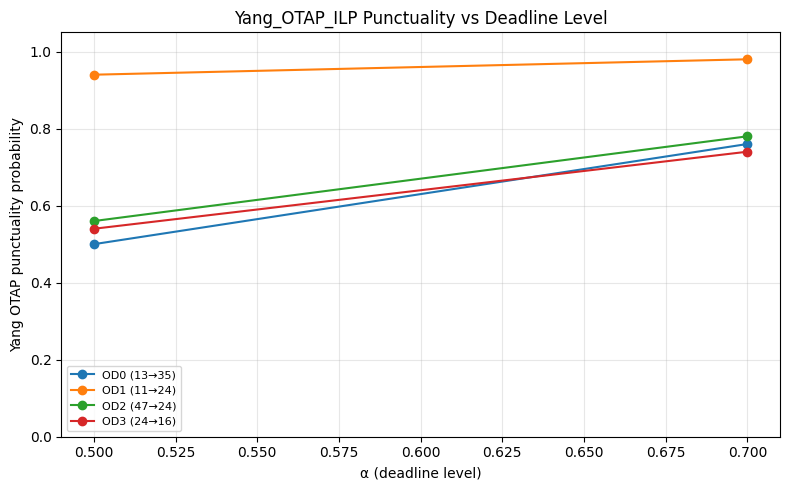

In [39]:
fig, ax = plt.subplots(figsize=(8, 5))

plot_df = df[(df["method"] == "Yang_OTAP_ILP") & df["punctuality_prob"].notna()]
for od_idx in sorted(plot_df["od_idx"].dropna().unique()):
    od_rows = plot_df[plot_df["od_idx"] == od_idx]
    origin = int(od_rows["origin"].iloc[0])
    dest = int(od_rows["destination"].iloc[0])
    od_rows = od_rows.sort_values("alpha")
    ax.plot(
        od_rows["alpha"],
        od_rows["punctuality_prob"],
        "o-",
        label=f"OD{int(od_idx)} ({origin}→{dest})",
        markersize=6,
    )

ax.set_xlabel("α (deadline level)")
ax.set_ylabel("Yang OTAP punctuality probability")
ax.set_ylim(0, 1.05)
ax.set_title("Yang_OTAP_ILP Punctuality vs Deadline Level")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 6. Save Results

In [40]:
OUTPUT_DIR = REPO_ROOT / "YangLixing_SOTA_TimeDependent" / "results" / "td_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

result.save_csv(OUTPUT_DIR / "results.csv")
result.summary().to_csv(OUTPUT_DIR / "summary.csv", index=False)
result.by_alpha().to_csv(OUTPUT_DIR / "by_alpha.csv", index=False)
result.by_od().to_csv(OUTPUT_DIR / "by_od.csv", index=False)
result.solve_time().to_csv(OUTPUT_DIR / "solve_time.csv", index=False)
result.status_counts().to_csv(OUTPUT_DIR / "status_counts.csv", index=False)

print(f"Results saved to: {OUTPUT_DIR}")
print(sorted(p.name for p in OUTPUT_DIR.glob("*.csv")))

Results saved to: /home/kkk/projects/RSP/YangLixing_SOTA_TimeDependent/results/td_notebook
['by_alpha.csv', 'by_od.csv', 'results.csv', 'solve_time.csv', 'status_counts.csv', 'summary.csv']


## 7. Advanced — From In-Memory Network Data

The public SDK also supports building a time-dependent dataset directly from a NetworkX graph with edge attributes. This is the path to use when you replace the network, OD pairs, and travel-time settings yourself.

In [41]:
import networkx as nx

G = nx.DiGraph()
G.add_edge(0, 1, mean_time=1.0, cv=0.10)
G.add_edge(1, 3, mean_time=1.0, cv=0.10)
G.add_edge(0, 2, mean_time=1.4, cv=0.20)
G.add_edge(2, 3, mean_time=1.4, cv=0.20)
G.add_edge(0, 3, mean_time=2.4, cv=0.35)

toy_td = RSPTimeDependentDataset.from_networkx(
    graph=G,
    od_pairs=[(0, 3)],
    time_profile=[1.0, 1.1, 1.35, 1.2, 1.0, 0.95, 1.05, 1.0],
    num_samples=20,
    time_step=1.0,
    random_seed=7,
    travel_time_source="edge_attributes",
    meta={"description": "toy time-dependent diamond"},
)

toy_cfg = RSPConfig(
    methods=("Yang_OTAP_ILP",),
    alphas=(0.5, 0.7),
    num_repeats=1,
    num_od_pairs=1,
    solver_backend=SOLVER_BACKEND,
    deadline_mode="exact",
    deadline_enumeration_cutoff=5,
    time_limit=20,
)

toy_result = RSPRunner(toy_td, toy_cfg).run(progress=False)
display(toy_result.by_alpha().round(4))

case_toy = RSPRunner(toy_td, toy_cfg).solve_case(repeat=0, od_idx=0, alpha=0.5)
y = case_toy.metrics["methods"]["Yang_OTAP_ILP"]
print(f"Yang path: {y['path_edges']}")
print(f"Punctuality: {y['punctuality_prob']:.4f}")
print(f"Conclusion: {y['conclusion']}")

,alpha,method,mean_punctuality_prob,mean_solve_time_s,optimal_rate,reference_available_rate,tie_aware_accuracy,path_match_accuracy,mean_objective_gap,mean_lateness_count,mean_on_time_count
0,0.5,Yang_OTAP_ILP,0.35,0.0117,1.0,0.0,NaN,NaN,NaN,13.0,7.0
1,0.7,Yang_OTAP_ILP,0.35,0.0099,1.0,0.0,NaN,NaN,NaN,13.0,7.0


Yang path: [(0, 3)]
Punctuality: 0.3500
Conclusion: Yang_OTAP_ILP found path [(0, 3)] with on-time probability 0.35 under threshold 2.11147; 7/20 samples arrive on time.


---

**Notes**

- `Yang_OTAP_ILP` requires `RSPTimeDependentDataset`; using it on static `RSPDataset` intentionally raises a clear error.
- The deadline `tau` is currently computed by aggregating `TD` into `W_deadline = mean_t TD` and reusing Cao's `alpha -> tau` mechanism.
- Time horizon matters. If the number of time steps is too short, a valid physical path can become infeasible in the time-expanded network.
